initialp = [2 2 2 2 2 2 2 2 2 2]
[0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25
 3.5  3.75 4.   4.25 4.5  4.75 5.  ] [[0, 1, 2], [np.int64(2), np.int64(3), np.int64(4)], [np.int64(4), np.int64(5), np.int64(6)], [np.int64(6), np.int64(7), np.int64(8)], [np.int64(8), np.int64(9), np.int64(10)], [np.int64(10), np.int64(11), np.int64(12)], [np.int64(12), np.int64(13), np.int64(14)], [np.int64(14), np.int64(15), np.int64(16)], [np.int64(16), np.int64(17), np.int64(18)], [np.int64(18), np.int64(19), np.int64(20)]]
initialp = [3 3 3 3 3 3 3 3 3 3]
[0.         0.16666667 0.33333333 0.5        0.66666667 0.83333333
 1.         1.16666667 1.33333333 1.5        1.66666667 1.83333333
 2.         2.16666667 2.33333333 2.5        2.66666667 2.83333333
 3.         3.16666667 3.33333333 3.5        3.66666667 3.83333333
 4.         4.16666667 4.33333333 4.5        4.66666667 4.83333333
 5.        ] [[0, 1, 2, 3], [np.int64(3), np.int64(4), np.int64(5), np.int64(6)], [np.int64(6)

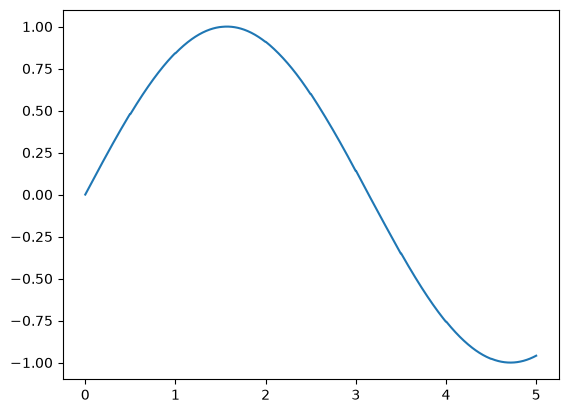

In [2]:
# Script params
# M - number of elements
# L length of simulation domain
# i, j - indices of gaussian integration legendre points within each cell
# p - order of hierarchical basis functions
# l - number of gauss legendre points?


import numpy as np
import scipy
import scipy.linalg
import scipy.sparse.linalg
sc = scipy
import matplotlib.pyplot as plt
 

def mesh(L, M, element_p_orders=None):
    """Mesh of M elements on [0, L] of equal physical size.
    will need to be tweaked for h-refinement, as will refinement function etc.

    """
    if element_p_orders is None:
        raise ValueError('element_p_orders must be provided')

    if isinstance(element_p_orders, int):
        element_p_orders = [element_p_orders] * M
    element_p_orders = np.asarray(element_p_orders, dtype=int)
    if len(element_p_orders) != M:
        raise ValueError(f'element_p_orders must have length M={M}, got {len(element_p_orders)}')

    total_dofs = int(np.sum(element_p_orders)) + 1
    nodes = np.linspace(0, L, total_dofs)

    elements = []
    offset = 0
    for p in element_p_orders:
        elements.append([offset + j for j in range(p + 1)])
        offset += p

    dx = L / M
    jac = [dx / 2.0 for _ in range(M)]  # dx/ds jacobian, constant since elements are equal-size
    print(nodes, elements)
    return nodes, elements, jac, element_p_orders, total_dofs
 
# def basis_eval(n, s):
#     """Hierarchical shape functions on the reference element [-1, 1]."""
#     f_base = np.zeros(n+1)
#     df_base = np.zeros(n+1)
#     for i in range(n+1):
#         if i == n+1:
#             f_base[i] = 0.5 * (1 + s)
#             df_base[i] = 0.5
#         elif i == 1:
#             f_base[i] = 0.5 * (1 - s)
#             df_base[i] = -0.5
#         else:
#             f_base[i] = 0.5 * (1 - s) * (1 + s) ** (i-1)
#             df_base[i] = 0.5 * (-(1 + s) ** (i-1) + (i-1) * (1 - s) * (1 + s) ** (i - 2))
        
#         print(f"Basis function {i}: f_base = {f_base[i]}, df_base = {df_base[i]}")
#     return f_base, df_base
 
 
def basis_eval(j, p, s):
    """Hierarchical shape functions on the reference element [-1, 1]."""

    if j == p+1:
        f_base = 0.5 * (1 + s)
        df_base = 0.5
    elif j == 1:
        f_base = 0.5 * (1 - s) * (1 + s) ** (j-1)
        df_base = -0.5
    else:
        f_base = 0.5 * (1 - s) * (1 + s) ** (j-1)
        df_base = 0.5 * (-(1 + s) ** (j-1) + (j-1) * (1 - s) * (1 + s) ** (j - 2))
        
        #print(f"Basis function {j}: f_base = {f_base}, df_base = {df_base}")
    return f_base, df_base





def K_integrals(p, i, j, alpha, beta, jacob):
    #'Integrals via gaussian quadrature for stiffness matrix', using 20 points purely to match Cam Key results
    x, w = np.polynomial.legendre.leggauss(20)
    integral = 0.0
    for q in range(len(x)):
        #f, df = basis_eval( n, x[q])
        # mass-like term uses the jacobian, stiffness-like term divides by it
        # (physical derivative = reference derivative / jacobian)
        integral += w[q] * ( basis_eval(i, p, x[q])[1] * basis_eval(j, p, x[q])[1])
    integral = -integral*alpha/jacob
    return integral
 
 
def M_integrals(p, i, j, beta, jacob):
    #'perform integrals via gaussian quadrature for mass matrix'
    x, w = np.polynomial.legendre.leggauss(20)
    integral = 0.0
    for q in range(len(x)):
        #f, df = basis_eval(i, n, x[q])
        #print(f)
        integral += w[q] *  basis_eval(i, p, x[q])[0] * basis_eval(j, p, x[q])[0]
    integral = integral*beta*jacob
    return integral
 
 
def K_fill_local(p_order, alpha, beta, jacob):
    #'Fill each element stiffness matrix'
    K_loc = np.zeros((p_order+1, p_order+1))
    for i in range(1, p_order+2):
        for j in range(1, p_order+2):
            K_loc[i-1, j-1] = K_integrals(p_order, i, j, alpha, beta, jacob)
    return K_loc
 
 
def M_fill_local(p_order, beta, jacob):
    #'Filling each block for each element of M_ij'
    M_loc = np.zeros((p_order+1, p_order+1))
    for i in range(1, p_order+2):
        for j in range(1, p_order+2):
            M_loc[i-1, j-1] = M_integrals(p_order, i, j, beta, jacob)
    return M_loc
 
 
def K_fill_global(M, meshy, alpha=1, beta=1):
    #'Stiffness matrix builder '
    nodes, elements, jac, p_orders, dof = meshy
    K_globe = np.zeros((len(nodes), len(nodes)))
    for e in range(M):
        elem = elements[e]
        current_jacob = jac[e]
        current_p_order = p_orders[e]
        K_loc = K_fill_local(current_p_order, alpha, beta, current_jacob)
        for i in range(current_p_order+1):
            for j in range(current_p_order+1):
                I = elem[i]
                J = elem[j]
                K_globe[I, J] += K_loc[i, j]
    return K_globe
 
 
def M_fill_global(M, meshy, beta=1):
    #"Mass matrix builder"
    nodes, elements, jac, p_orders,dof = meshy
    M_globe = np.zeros((len(nodes), len(nodes)))
    for e in range(M):
        elem = elements[e]
        current_jacob = jac[e]
        current_p_order = p_orders[e]
        M_loc = M_fill_local(current_p_order, beta, current_jacob)
        for i in range(current_p_order+1):
            for j in range(current_p_order+1):
                I = elem[i]
                J = elem[j]
                M_globe[I, J] += M_loc[i, j]
    return M_globe
 
 
def weights_unknown(N):
    return np.zeros(N)
 
 
def G_assemble(g, meshy):
    #"excitation vector ==0 unless other g specified"
    nodes, elements, jac, p_orders, dof = meshy
    G = np.zeros(dof)
    if g != 0:
        G[:] = g
    return G
 
 
def boundary(G, K, L, btype):
    #""'Neumann BC as specified in the problem statement. Dirichlet not yet defined, will need to do so'
    #A bit confused on implementing and derivign different BC. Think I am rusty
    G = G.copy()
    K = K.copy()
    if btype == 'dirichlet':
        G[0] = 1
        G[-1] = -np.cos(L)
    elif btype == 'neumann':
        G[0] = 1
        G[-1] = -np.cos(L)
    return G, K
 
 
def waveguide(K, Mmat):
    # This is not necessarily fully incorporated into the overally p-refining scheme
    # eigenproblem K x = lambda Mmat x 
    vals, vecs = scipy.linalg.eig(K, Mmat)
    return vals, vecs
 
 
def scattering(K, G,L):
    soln = scipy.linalg.solve(K, G)
    #error = error_scatter(soln,L)
    return soln
 
 
def HW(K, G,L):
    #soln = scipy.linalg.solve(K, G)
    #error = error_scatter(soln,L)
    soln = np.linalg.inv(K).dot(G)
    
    return soln




 
def local_errors(approx, exact, L, M,n):
    """Compute local errors for each element."""
    nodes, elements, jac, p_orders = mesh(L, M, n)
    local_errors = np.zeros(M)
    for e in range(M):
        elem = elements[e]
        approx_local = approx[elem]
        exact_local = exact[elem]
        local_errors[e] = np.sqrt(np.sum((approx_local - exact_local) ** 2))
    return local_errors


def p_refine(mesh_info, local_errors, threshold):
    sort_indices = np.argsort(local_errors,descending=True)
    sorted_errors = np.sort(local_errors,descending=True)
    top_to_refine = sort_indices[:len(sorted_errors)//3]
    refine = local_errors[top_to_refine]
    new_mesh_info = mesh_info
    mesh_elem = mesh_info[1]
    for i in range(len(refine)):
        if refine[i] > threshold:
            new_mesh_info[3][mesh_elem.index(top_to_refine[i])] += 1  
        else:
            break
    return new_mesh_info


def dual_weight_residual_global(solution, higher_order_soln):
    '''Computing DWR for the whole domain, using the solution and enriched solution to error estimate.
    In this case the operator L is self adjoint, so dual is same as primal, but the excitation is 
    then the divergence of the primal solution, giving the "charge" density to the primals E field.'''

    
    soln = solution
    enriched_soln = higher_order_soln
    interpolated_soln = np.interp(np.linspace(0, 1, len(enriched_soln)), np.linspace(0, 1, len(soln)), soln)
    error_estimate = np.gradient(enriched_soln) - np.gradient(interpolated_soln)
    inner_product = np.dot(enriched_soln, interpolated_soln)
    DWR = np.abs(inner_product) * error_estimate

    return DWR



def basis_scale_plotting(solution_in, L, M, mesh):
    '''From Cam Key code (adapted) scales the solution to the physical output!'''
    nodes, elems, jac, p_order, dof = mesh
    s = np.linspace(-1, 1, 100)
    plot_samps = np.zeros(M * 100)
    s_len = len(s)
    for e in range(M):
        elem = elems[e]
        for j_local in range(1, p_order[e] + 2):
            coeff = solution_in[elem[j_local - 1]]
            for k in range(s_len):
                plot_samps[e * s_len + k] += coeff * basis_eval(j_local, p_order[e], s[k])[0]
    return plot_samps




def p_refine_DWR_global(type, L, M, p_orders, g=0):
    # Use the DWR to refine the mesh with p refinement - no longer only globally
    p_orders = np.asarray(p_orders, dtype=int)
    low_order, low_order_plotting, mesher1 = main(p_orders, type, L, M, g)
    high_order, high_order_plotting, mesher2 = main(p_orders + 1, type, L, M, g)
    DWR = dual_weight_residual_global(low_order_plotting, high_order_plotting)
    error_indicators = DWR * high_order_plotting
    print(f'length of error: {len(error_indicators)}')
    return DWR, error_indicators, low_order_plotting, mesher1




def refinement(threshold, type, L, M, n=2, p_orders=None, g=0):
    # basically the main function. Could be better organized for sure, but this works to test it out. 
    if p_orders is None:
        p_orders = np.array([n] * M, dtype=int)
    else:
        p_orders = np.asarray(p_orders, dtype=int)
    
    max_iter = 10
    errors_store = []
    solutions_store = []
    for iteration in range(max_iter):
        dwr, errors, low_order_plotting, mesh = p_refine_DWR_global(type, L, M, p_orders, g)
        nodes, elements, jac, p_orders_mesh, degrees = mesh
        errors_store.append(errors)
        solutions_store.append(low_order_plotting)
        samples_per_element = len(errors) // M
        
        element_errors = np.zeros(M)
        for e in range(M):
            start = e * samples_per_element
            stop = start + samples_per_element
            element_errors[e] = np.sum(errors[start:stop])

        print(f'Iteration {iteration}: p_orders={p_orders.tolist()}, error_max={element_errors.max():.6g}')

        if element_errors.max() <= threshold:
        
            return dwr, errors, low_order_plotting, mesh, solutions_store, errors_store

        marked = np.argsort(element_errors)[-max(1, M // 3):]
        p_orders = p_orders.copy()
        p_orders[marked] += 1
    #plotting_solution_error(L,M, low_order_plotting, errors)
    print('refinement: reached max iterations without meeting threshold')
    return dwr, errors, low_order_plotting, mesh, solutions_store, errors_store



def main(init_element_p_orders,type='HW', L=5, M=10, g=0):
    #init_element_p_orders = [n] * M
    print(f'initialp = {init_element_p_orders}')
    mesher = mesh(L, M, init_element_p_orders)
    #print(f'mesher {mesher}')
    #rint("Mesher:", mesher)
    K = K_fill_global(M, mesher)
    #print("K:", K)
    #print("Shape of K:", np.shape(K))
    #print("K:", K)
    
    #print(K)
    Mmat = M_fill_global(M, mesher)
    #print("Mmat:", Mmat)
    #print(Mmat)
    G = G_assemble(g, mesher)
    G, K = boundary(G, K, L, 'neumann')
    #print("K:", G)
    #weights = weights_unknown(M * n + 1)
 
    if type == 'waveguide':
        soln = waveguide(K, Mmat)
    elif type == 'scattering':
        K = K+Mmat
        
        soln = scattering(K, G, L)
        

            
    else:
        K = K+Mmat
        #print("K+M:", K)
        #print("Shape of K+M:", np.shape(K))
        #DWR = [1]
        #if DWR < 1:
        #    p_refine_DWR_global(1e-3, 'HW', L=5, M=1, n=2)
        soln = HW(K, G, L)
        plotting_soln = basis_scale_plotting(soln, L, M, mesher)
        #print("Plotting solution shape:", solution)

    return soln, plotting_soln, mesher


def plotting_solution_error(L,M, solve, error):
    x = np.linspace(0,L,M)
    plt.figure(10,6)
    plt.plot(x, solve[0])
    plt.plot(x, solve[1])


    plt.figure(10,6)
    plt.plot(np.linspace(0,len(error),len(error)), error)



dwr, errors, low_order_plotting, meshed,errorstore, solutionstore  = refinement(1e-2, 'HW',5,10,2)
    #plotting_solution_error(L,M, solve, error)

nodes, elements, jac, element_p_orders, total_dofs = meshed
print(f'elements: {elements}')

# analytic solution is sin(x), so we should see that here.
#print(f'solutions: {solutionstore}')
plt.plot(np.linspace(0,5,len(low_order_plotting)),low_order_plotting)
plt.show()



In [10]:

p_orders = [2,2]
elements = np.array([np.array([1,2,3,4,5]),np.array([5,6,7,8,9])])
marking = [0]

# function to test out h-refinemetn by starting with the lement continuity aspect!
# Need to add node requirements and dof for p - orders and such things. and insure that these are compatibel with the 
# h-refinement.
def h_refine(mesh_initial,marking_indices,element_p_orders,L):
    elems_new = []
    #nodes, elements = mesh()
    midpoints = [] # to be used for dof/mesh computation later. because we are adding a new node

    
    for i in range(len(mesh_initial)):


        if i in marking_indices:


            midpoint = mesh_initial[i][len(mesh_initial[i])//2]
            midpoints.append(midpoint)
            print(midpoint)
            left = mesh_initial[i][:len(mesh_initial[i])//2]
            right = mesh_initial[i][len(mesh_initial[i])//2:]


            if midpoint in left:
                elems_new.append(left)
                right = np.insert(right, 0, midpoint)
                elems_new.append(right)


            else:
                left = np.insert(left,len(left),midpoint)
                elems_new.append(left)
                elems_new.append(right)


            #print(left)
            element_p_orders.insert(i, p_orders[i])


        else:

            # Keep non-refined elements unchanged.
            elems_new.append(np.array(mesh_initial[i], dtype=int).copy())
    nodes = []
    for i in range(len(elems_new)):
        nodes.append([elems_new[i][0], elems_new[i][-1]])
        node_unique = np.unique(nodes)
    


    return elems_new, element_p_orders, midpoint, marking_indices, node_unique


elem, ps, mids, marking_indices, nodes = h_refine(elements, marking, p_orders,10)


print(elem)

print(ps)

print(nodes)

3
[array([1, 2, 3]), array([3, 4, 5]), array([5, 6, 7, 8, 9])]
[2, 2, 2]
[1 3 5 9]


In [ ]:

def legendre_smoothness_assessment(plotting_soln,plotting_soln_x, elements):
    # function to decide on h vs p refinement based on smoothness of legendre approximation on each element
    # this is supposed to be for the enriched solution used to compute the adjoint. I do not have this fully sorted out yet.
    coeff = []
    def decay_exp(x,a, sigma):
        return a* np.exp(sigma* x)
    decay = []
    for i in range(len(elements)):
        elem_borders = [elements[i][0],elements[i][-1]]

        coeff.append(numpy.legfit(plotting_soln_x[elem_borders[0]:elem_borders[1]],plotting_soln[elem_borders[0]:elem_borders[1]]))
        decay.append(sigma = sc.curvefit(decay_exp, coeff))

    # compute the decay rate of the fit for each element 
    h_marked = []
    for i in range(len(elements)):
        if decay(i) < 3:
            h_marked[i] = 1
        else:
            h_marked[i] = 0

    return  h_marked




In [ ]:
# Refinement algorithm steps - now that h-refining is being incorporated:

# if error indicator high
# take enriched solution from adjoint - into the legendre smoothness function:
# mark for h refinement
# p - refining function already marks for refinemetn based on adjoint so need to take the marked elemetns from there and send thos to the 
#legendre smoothness function to then decide on refinement type!